# GIAI ĐOẠN 2: XÂY DỰNG MÔ HÌNH TOÁN HỌC IRT (Item Response Theory)

### 1. Các tham số chính trong Mô hình 2PL
Thay vì đánh giá câu hỏi dựa trên tổng số người làm đúng một cách cảm tính, IRT định lượng bằng các biến số toán học độc lập:

* **Năng lực học sinh (Student Ability - $\theta$):** Năng lực thực chất của học sinh. Tham số này được tính toán dựa trên độ khó của những câu hỏi mà học sinh đó đã vượt qua, thay vì chỉ đếm số lượng câu đúng.
* **Độ khó thực sự của câu hỏi (Question Difficulty - $b$):** Điểm giới hạn mà tại đó học sinh có 50% xác suất trả lời đúng. Tham số độ khó này **độc lập với năng lực của nhóm học sinh làm bài** (loại bỏ được hiện tượng câu hỏi trông có vẻ dễ chỉ vì vô tình rơi vào nhóm học sinh quá giỏi).
* **Độ phân biệt (Discrimination - $a$):** Khả năng của câu hỏi trong việc phân tách rõ ràng giữa học sinh "Giỏi" và "Yếu". Một câu hỏi có độ phân biệt lý tưởng là câu mà học sinh giỏi chắc chắn làm đúng, còn học sinh yếu chắc chắn làm sai (không thể đoán lụi).

### 2. Kế hoạch tính toán (Tiếp cận bằng Proxy)
Để xây dựng mô hình, trước tiên ta cần tính toán các giá trị đại diện (Proxy) ban đầu từ tập dữ liệu lớn:
1. **Ước lượng Proxy Năng lực học sinh:** Tính toán tỷ lệ trả lời đúng tổng thể của từng cá nhân (chỉ lọc xét các học sinh đã làm $\ge$ 10 câu để đảm bảo độ tin cậy của dữ liệu).
2. **Ước lượng Proxy Độ khó câu hỏi:** Tính toán tỷ lệ trả lời sai của từng câu hỏi riêng biệt.

In [11]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('data/train_cleaned.csv')
df_parts = pd.read_csv('data/train_merged_with_parts.csv')

print(f"Đã nạp thành công {len(df_train)} dòng dữ liệu!")
df_train.head()

Đã nạp thành công 4812958 dòng dữ liệu!


,row_id,timestamp,user_id,content_id,content_type_id,task_container_id,user_answer,answered_correctly,prior_question_elapsed_time,prior_question_had_explanation
0,0,0,115,5692,0,1,3,1,NaN,NaN
1,1,56943,115,5716,0,2,2,1,37000.0,False
2,2,118363,115,128,0,0,0,1,55000.0,False
3,3,131167,115,7860,0,3,0,1,19000.0,False
4,4,137965,115,7922,0,4,1,1,11000.0,False


### Bước 1.1: Tính tỷ lệ đúng của từng học sinh

In [12]:
# Gom nhóm toàn bộ dữ liệu theo từng học sinh (user_id)
nhom_hoc_sinh = df_train.groupby('user_id')

# Tính tỷ lệ đúng (mean) và số câu đã làm (count)
student_ability = nhom_hoc_sinh['answered_correctly'].agg(['mean', 'count']).reset_index()
student_ability.rename(columns={'mean': 'ability_score', 'count': 'total_answered'}, inplace=True)

print("Top 5 học sinh có năng lực cao nhất:")
display(student_ability.sort_values(by='ability_score', ascending=False).head())

Top 5 học sinh có năng lực cao nhất:


,user_id,ability_score,total_answered
13675,98596877,1.000000,30
6304,45312560,1.000000,30
6650,48102728,1.000000,41
4895,35662893,0.989011,91
1028,7528236,0.967742,31


### Bước 1.2: Tính độ khó câu hỏi

In [13]:
# Gom nhóm toàn bộ dữ liệu theo từng id câu hỏi (content_id) để tính tỉ lệ trả lời đúng cho mỗi câu hỏi

question_diff = df_train.groupby('content_id')['answered_correctly'].agg(['mean', 'count']).reset_index()
question_diff.rename(columns={'mean': 'correct_rate', 'count': 'times_asked'}, inplace=True)

# Tham số IRT: Độ khó = 1 - Tỷ lệ đúng
question_diff['difficulty_score'] = 1 - question_diff['correct_rate']

print("Top 5 câu hỏi khó nhất:")
question_diff.sort_values(by='difficulty_score', ascending=False).head()

Top 5 câu hỏi khó nhất:


,content_id,correct_rate,times_asked,difficulty_score
1308,1308,0.0,4,1.0
8470,8504,0.0,1,1.0
2077,2080,0.0,1,1.0
8015,8049,0.0,1,1.0
4383,4393,0.0,1,1.0


Trực quan hóa (Scatter Plot)

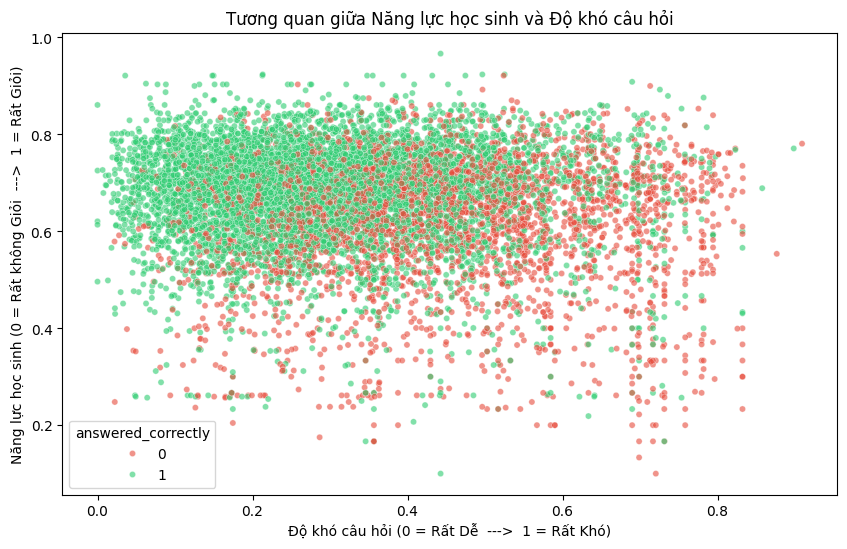

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy ngẫu nhiên 10.000 lượt tương tác để vẽ (tránh làm tràn RAM khi vẽ hình)
df_sample_plot = df_train.sample(n=10000, random_state=42)

# Ghép điểm Năng lực và Độ khó vào bảng vẽ
df_sample_plot = df_sample_plot.merge(student_ability[['user_id', 'ability_score']], on='user_id', how='inner')
df_sample_plot = df_sample_plot.merge(question_diff[['content_id', 'difficulty_score']], on='content_id', how='inner')

# Bắt đầu vẽ Biểu đồ Phân tán
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample_plot, 
    x='difficulty_score', 
    y='ability_score', 
    hue='answered_correctly', 
    palette={1: '#2ecc71', 0: '#e74c3c'}, # Xanh: Đúng và Đỏ: Sai
    alpha=0.6,
    s=20 # Kích thước hạt
)

plt.title('Tương quan giữa Năng lực học sinh và Độ khó câu hỏi')
plt.xlabel('Độ khó câu hỏi (0 = Rất Dễ  --->  1 = Rất Khó)')
plt.ylabel('Năng lực học sinh (0 = Rất không Giỏi  --->  1 = Rất Giỏi)')
plt.show()

c:\Users\Thy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Thy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Thy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Thy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


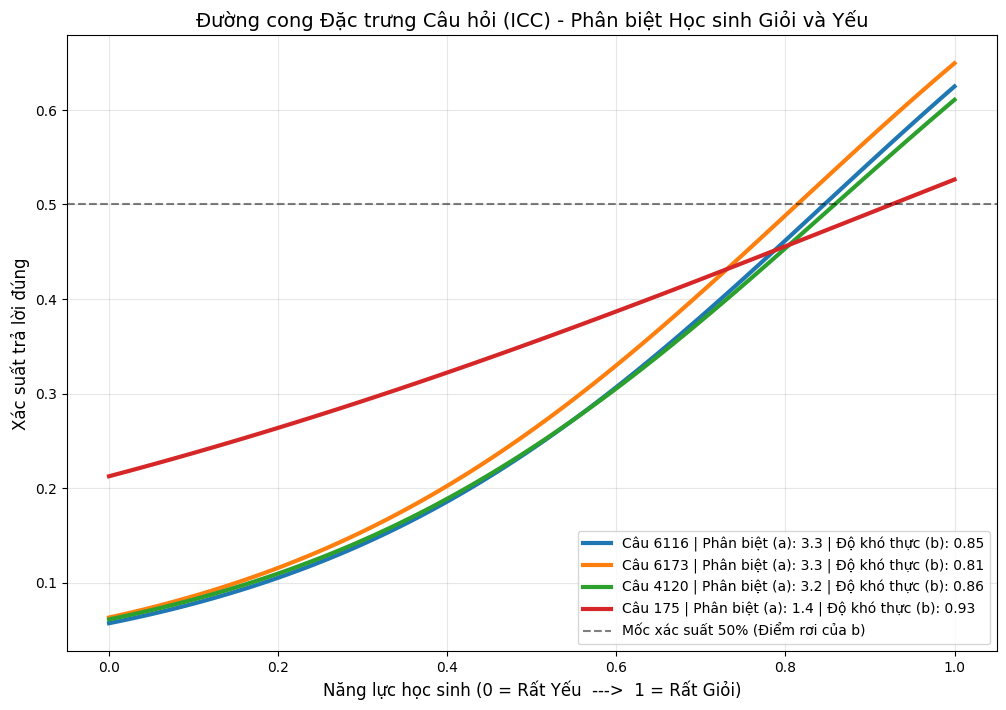

In [17]:
# BƯỚC 4: ỨNG DỤNG MACHINE LEARNING ĐỂ TÌM ĐỘ KHÓ THỰC SỰ VÀ ĐỘ PHÂN BIỆT (Mô hình IRT 2PL)
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Chọn ra 4 câu hỏi có nhiều người làm nhất để phân tích cho chuẩn xác
top_questions = df_train['content_id'].value_counts().head(4).index
df_icc = df_train[df_train['content_id'].isin(top_questions)].copy()

# 2. Ghép điểm năng lực học sinh vào
df_icc = df_icc.merge(student_ability[['user_id', 'ability_score']], on='user_id', how='inner')

# 3. Chuẩn bị vẽ đường cong (ICC)
plt.figure(figsize=(12, 8))

for q_id in top_questions:
    df_q = df_icc[df_icc['content_id'] == q_id]
    
    # Biến đầu vào X (Năng lực), Đầu ra y (Trả lời Đúng 1 / Sai 0)
    X = df_q[['ability_score']]
    y = df_q['answered_correctly']
    
    # Huấn luyện mô hình Logistic Regression (đại diện cho hàm Toán học của IRT)
    model = LogisticRegression()
    model.fit(X, y)
    
    # Bóc tách tham số Toán học
    a = model.coef_[0][0] # Độ phân biệt (Slope)
    intercept = model.intercept_[0]
    b = -intercept / a    # Độ khó thực sự (Điểm năng lực để P(đúng) = 50%)
    
    # Dự đoán xác suất cho dải năng lực từ 0 đến 1
    x_vals = np.linspace(0, 1, 100)
    y_vals = model.predict_proba(x_vals.reshape(-1, 1))[:, 1]
    
    # Vẽ đường cong lên biểu đồ
    plt.plot(x_vals, y_vals, linewidth=3, 
             label=f'Câu {q_id} | Phân biệt (a): {a:.1f} | Độ khó thực (b): {b:.2f}')

# Thêm đường cắt 50% để xác định độ khó thực sự
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Mốc xác suất 50% (Điểm rơi của b)')

plt.title('Đường cong Đặc trưng Câu hỏi (ICC) - Phân biệt Học sinh Giỏi và Yếu', fontsize=14)
plt.xlabel('Năng lực học sinh (0 = Rất Yếu  --->  1 = Rất Giỏi)', fontsize=12)
plt.ylabel('Xác suất trả lời đúng', fontsize=12)
plt.legend(fontsize=10, loc='lower right')
plt.grid(alpha=0.3)
plt.show()